# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Nguyen Huu Thien"  # TODO: Họ và tên
STUDENT_ID = "2413284"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyen Huu Thien (2413284)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\ADMIN\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
shifted_logits = logits - logits.max(axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / exp_logits.sum(axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

print("shifted_logits:\n", shifted_logits)
print("class_probabilities:\n", class_probabilities)
print("predicted_classes:", predicted_classes)
print("confidence_scores:", confidence_scores)

shifted_logits:
 [[ 0.  -1.  -1.9]
 [-1.   0.  -2. ]
 [-5.  -4.   0. ]
 [ 0.   0.   0. ]]
class_probabilities:
 [[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]
predicted_classes: [0 1 2 0]
confidence_scores: [0.65900114 0.66524096 0.97555875 0.33333333]


In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

print("train_feature_mean:", train_feature_mean)
print("train_feature_std:", train_feature_std)
print("X_train_scaled:\n", X_train_scaled)
print("X_val_scaled:\n", X_val_scaled)


train_feature_mean: [172.5         69.16666667   1.65        28.16666667]
train_feature_std: [ 7.47774476 13.04372987  0.79109629  7.64671316]
X_train_scaled:
 [[-0.3343254  -0.31943828 -0.56883088 -0.80644671]
 [ 1.0029762   0.83053953  0.94805147  0.89363014]
 [-1.671627   -1.4694161  -1.07445834 -1.19877214]
 [ 0.3343254   0.06388766 -0.18961029 -0.02179586]
 [-0.60178572 -0.70276422 -0.82164461 -0.54489643]
 [ 1.27043652  1.59719141  1.70649265  1.67828099]]
X_val_scaled:
 [[-0.06686508 -0.08944272 -0.31601716 -0.28334614]
 [ 2.34027779  1.98051735  2.21212011  2.20138156]]


In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = (~correct_mask) | (~high_confidence_mask)
review_indices = np.where(review_mask)[0]

print("correct_mask:", correct_mask)
print("high_confidence_mask:", high_confidence_mask)
print("review_mask:", review_mask)
print("review_indices:", review_indices)

correct_mask: [ True False  True False]
high_confidence_mask: [False False  True False]
review_mask: [ True  True False  True]
review_indices: [0 1 3]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

# Flip theo trục width (axis=2 trong layout B, H, W, C), copy() de co bo nho doc lap
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

print("normalized_batch dtype/range:", normalized_batch.dtype, normalized_batch.min(), normalized_batch.max())
print("augmented_batch[0,0,0,0]:", augmented_batch[0, 0, 0, 0])
print("normalized_batch[0,0,0,0]:", normalized_batch[0, 0, 0, 0])


normalized_batch dtype/range: float32 0.0 0.37254903
augmented_batch[0,0,0,0]: 1.0
normalized_batch[0,0,0,0]: 0.0


# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời** 

1. Mỗi dòng đại diện cho một phiên bản xe cụ thể.
2. Ký hiệu missing value trong CSV là dấu `?`.
3. `symboling` là mức độ rủi ro bảo hiểm do bên bảo hiểm gán cho xe, giá trị từ -3 (an toàn) đến 3 (rủi ro cao); xe có mức phí bảo hiểm cao hơn mức trung bình của phân khúc sẽ bị đẩy về phía dương (+).


## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
raw_missing_marker_count = int((raw_df.astype(str) == "?").sum().sum())

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)
raw_df.head()

raw_shape: (205, 26)
raw_missing_marker_count: 59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace("?", np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors="coerce")

missing_by_column = df_clean.isna().sum().sort_values(ascending=False)
print(missing_by_column[missing_by_column > 0])


normalized_losses    41
stroke                4
price                 4
bore                  4
horsepower            2
peak_rpm              2
num_doors             2
dtype: int64


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

- Không nên fill tất cả numeric columns bằng cùng một giá trị vì các cột có đơn vị và phân phối rất khác nhau (giá tiền, mã lực, kích thước...), tránh làm méo thống kê và mối quan hệ giữa các biến. 
- Với `price` — đây là biến mục tiêu chính của bài và chỉ thiếu 4/205 dòng, nên drop các dòng đó phù hợp hơn fill, vì fill giá trị cho biến mục tiêu dễ tạo ra tín hiệu giả trong các phân tích về giá. 
- `normalized_losses` thiếu tới 41/205 dòng (~20%), nếu fill bằng mean/median sẽ làm giảm phương sai thật của cột và có thể làm sai lệch các correlation liên quan, hợp lý hơn là loại `normalized_losses` khỏi các phân tích số liệu sâu, hoặc chỉ dùng nó cho các câu hỏi không quan trọng.


## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean.dropna(subset=AUTO_FEATURES).reset_index(drop=True)
X_auto = analysis_df[AUTO_FEATURES].to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

print("analysis_df shape:", analysis_df.shape)
print("auto_feature_mean:\n", auto_feature_mean)
print("auto_feature_std:\n", auto_feature_std)

analysis_df shape: (199, 26)
auto_feature_mean:
 [ 2556.03015075   126.8241206    103.39698492    25.20100503
    30.68341709 13243.4321608 ]
auto_feature_std:
 [5.18547730e+02 4.16478926e+01 3.74593675e+01 6.43559503e+00
 6.83217899e+00 7.95863536e+03]


## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = AUTO_FEATURES.index("price")
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = np.abs(price_z) > 2
price_outliers = analysis_df.loc[price_outlier_mask, ["make", "body_style", "price"]]

print("So luong outlier:", price_outlier_mask.sum())
price_outliers

So luong outlier: 14


,make,body_style,price
14,bmw,sedan,30760.0
15,bmw,sedan,41315.0
16,bmw,sedan,36880.0
44,jaguar,sedan,32250.0
45,jaguar,sedan,35550.0
46,jaguar,sedan,36000.0
67,mercedes-benz,sedan,31600.0
68,mercedes-benz,sedan,34184.0
69,mercedes-benz,convertible,35056.0
70,mercedes-benz,sedan,40960.0


## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
engine_index = AUTO_FEATURES.index("engine_size")
engine_price_corr = np.corrcoef(X_auto[:, engine_index], X_auto[:, price_index])[0, 1]

price_by_body_style = analysis_df.groupby("body_style")["price"].mean().sort_index()

print("engine_price_corr:", engine_price_corr)
print(price_by_body_style)

engine_price_corr: 0.8738869517981515
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9958.373134
sedan          14459.755319
wagon          12500.166667
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

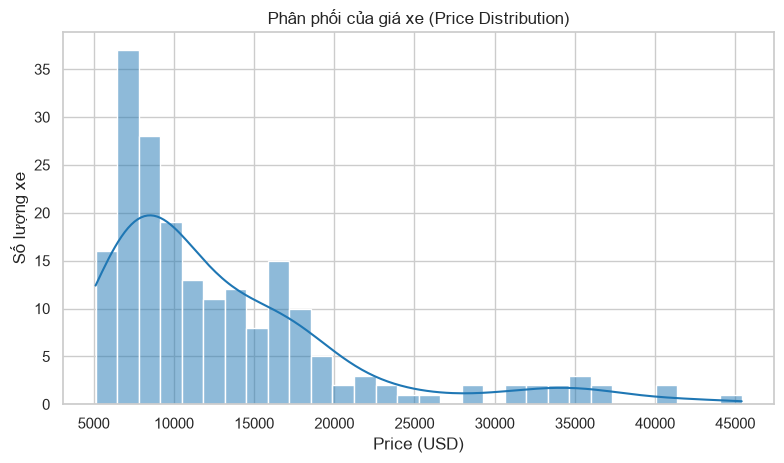

In [20]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots()
sns.histplot(analysis_df["price"], kde=True, bins=30, color="tab:blue", ax=ax)
ax.set_title("Phân phối của giá xe (Price Distribution)")
ax.set_xlabel("Price (USD)")
ax.set_ylabel("Số lượng xe")
plt.tight_layout()
plt.show()

**Nhận xét:** 
- Phân phối `price` lệch phải (right-skewed) rõ rệt: phần lớn xe có giá dưới 15,000 USD (median ≈ 10,345 USD) trong khi một nhóm nhỏ xe cao cấp kéo giá lên tới hơn 40,000 USD, làm trung bình (≈13,243 USD) cao hơn median.


## M2.2 Dataset có cân bằng theo body style không?

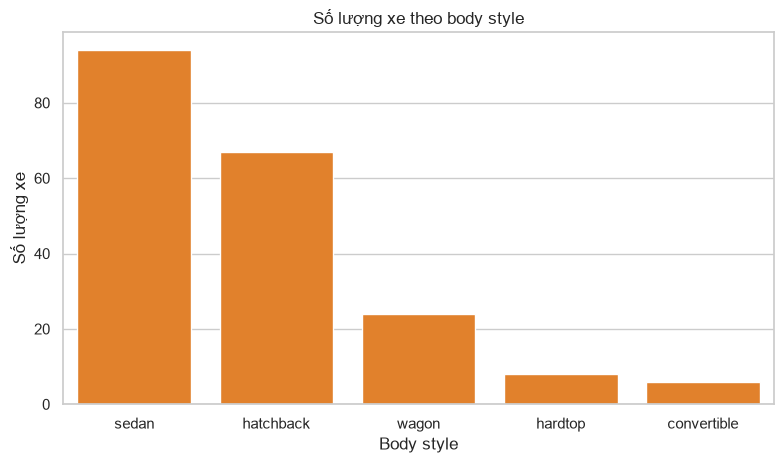

In [21]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots()
order = analysis_df["body_style"].value_counts().index
sns.countplot(data=analysis_df, x="body_style", order=order, color="tab:orange", ax=ax)
ax.set_title("Số lượng xe theo body style")
ax.set_xlabel("Body style")
ax.set_ylabel("Số lượng xe")
plt.tight_layout()
plt.show()

**Nhận xét:** 
- Dataset không cân bằng theo body style: `sedan` (94 xe) và `hatchback` (67 xe) chiếm phần lớn, trong khi `convertible` (6 xe) và `hardtop` (8 xe) rất ít mẫu, nên các kết luận về hai nhóm này cần thận trọng.

## M2.3 Price khác nhau theo body style ra sao?

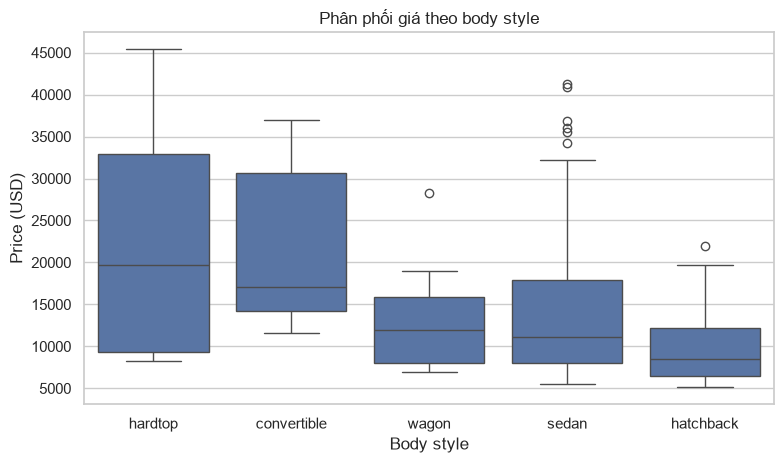

In [22]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots()
order = analysis_df.groupby("body_style")["price"].median().sort_values(ascending=False).index
sns.boxplot(data=analysis_df, x="body_style", y="price", order=order, ax=ax)
ax.set_title("Phân phối giá theo body style")
ax.set_xlabel("Body style")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()


**Nhận xét:**
- `convertible` và `hardtop` có giá trung bình cao nhất (~22,000 USD), trong khi `hatchback` có giá trung bình thấp nhất (~9,958 USD); `sedan` tuy đông nhất nhưng giá trải khá rộng, cho thấy body style ảnh hưởng rõ đến phân khúc giá.

## M2.4 Engine size liên quan thế nào tới price?

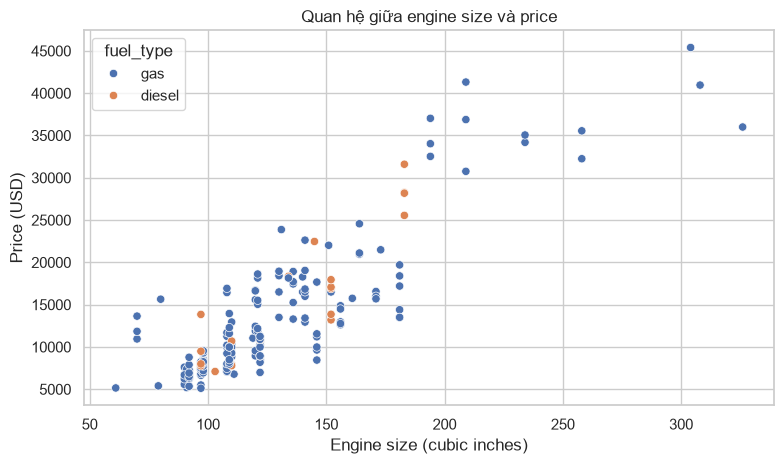

In [23]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots()
sns.scatterplot(data=analysis_df, x="engine_size", y="price", hue="fuel_type", ax=ax)
ax.set_title("Quan hệ giữa engine size và price")
ax.set_xlabel("Engine size (cubic inches)")
ax.set_ylabel("Price (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:**
- Engine size và price có tương quan dương khá mạnh (Pearson r ≈ 0.87) — xe động cơ lớn hơn có xu hướng giá cao hơn rõ rệt; xe chạy diesel có xu hướng nằm ở nhóm engine size trung bình nhưng giá không thấp hơn xe gas tương ứng.


## M2.5 Các feature numeric tương quan ra sao?

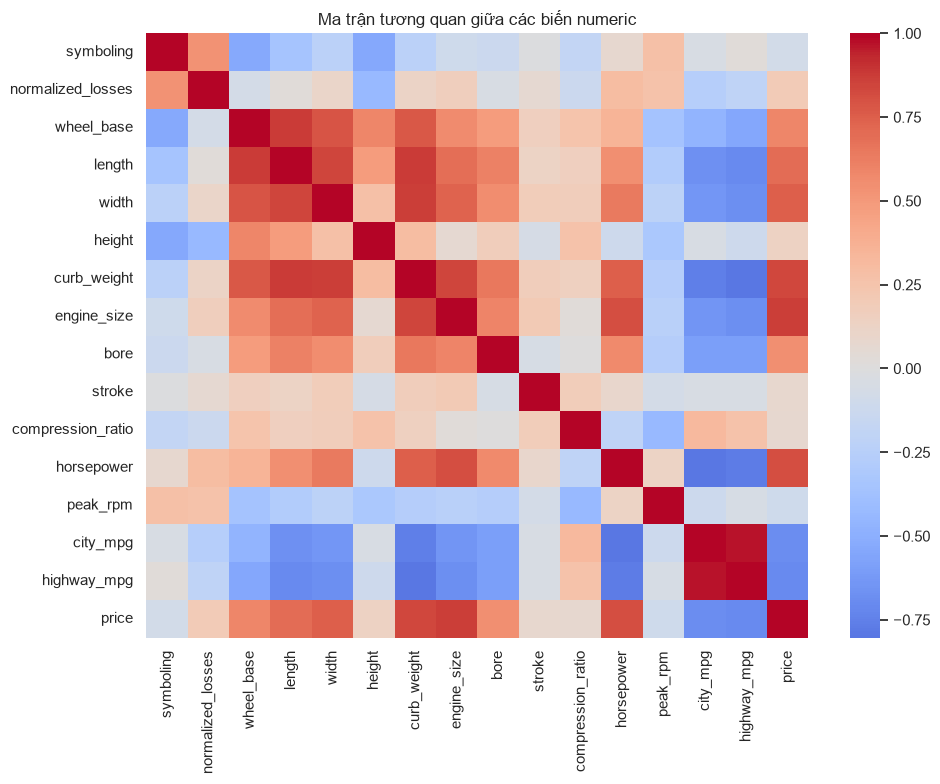

In [24]:
# TODO M2.5: correlation heatmap
corr_matrix = df_clean[NUMERIC_COLUMNS].corr()
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, ax=ax)
ax.set_title("Ma trận tương quan giữa các biến numeric")
plt.tight_layout()
plt.show()

**Nhận xét:** 
- `curb_weight`, `engine_size` và `horsepower` tương quan dương mạnh với `price` và với nhau, trong khi `city_mpg`/`highway_mpg` tương quan âm mạnh với các biến kích thước/công suất và với `price` — phản ánh việc xe càng lớn, càng mạnh thì càng tốn nhiên liệu và càng đắt.


## M2.6 Biểu đồ tự chọn

- Giá trung binh theo drive_wheels như thế nào?

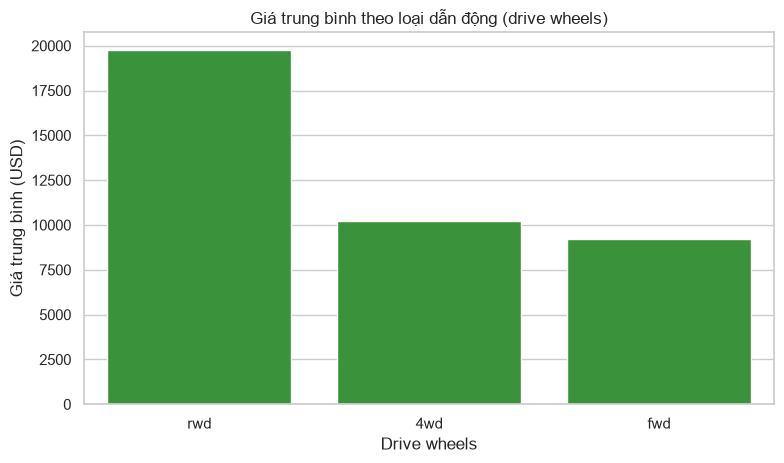

In [25]:
# TODO M2.6: biểu đồ tự chọn 
fig, ax = plt.subplots()
price_by_drive = analysis_df.groupby("drive_wheels")["price"].mean().sort_values(ascending=False)
sns.barplot(x=price_by_drive.index, y=price_by_drive.values, color="tab:green", ax=ax)
ax.set_title("Giá trung bình theo loại dẫn động (drive wheels)")
ax.set_xlabel("Drive wheels")
ax.set_ylabel("Giá trung bình (USD)")
plt.tight_layout()
plt.show()

**Nhận xét:**
- Xe dẫn động cầu sau (`rwd`) có giá trung bình cao nhất (≈19,758 USD), gấp khoảng 2 lần so với `4wd` (≈10,241 USD) và `fwd` (≈9,239 USD) — phù hợp với thực tế `rwd` thường xuất hiện ở các dòng xe thể thao/hạng sang trong dataset này.


# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

Dữ liệu Automobile gồm 205 dòng, mỗi dòng là một phiên bản xe cụ thể, với dấu `?` được dùng để đánh dấu giá trị thiếu. Sau khi làm sạch, `normalized_losses` là cột thiếu nhiều nhất (41 dòng), còn `price`, `bore`, `stroke` chỉ thiếu 4 dòng mỗi cột.

**Các phát hiện chính:**
1. `price` lệch phải mạnh, đa số xe dưới 15,000 USD nhưng có đuôi dài các xe hạng sang (BMW, Jaguar, Mercedes-Benz, Porsche) lên đến hơn 40,000 USD — đây cũng chính là 14 điểm bị đánh dấu outlier theo z-score (|z| > 2).
2. `engine_size` tương quan dương mạnh với `price` (r ≈ 0.87), là một trong những yếu tố dự đoán giá tốt nhất trong dataset.
3. Các biến kích thước/công suất xe (`curb_weight`, `engine_size`, `horsepower`) tương quan dương với nhau và âm với mức tiêu hao nhiên liệu (`city_mpg`, `highway_mpg`).
4. Body style ảnh hưởng rõ đến giá: `convertible`/`hardtop` có giá trung bình cao nhất, `hatchback` thấp nhất.
5. Dẫn động `rwd` có giá trung bình cao gấp đôi `fwd`/`4wd`, phần lớn do trùng với các xe thể thao/hạng sang trong mẫu.

**Hạn chế của dataset:**
- Kích thước mẫu nhỏ (205 dòng) và phân bố không cân bằng giữa các body style (`convertible` chỉ có 6 xe) khiến kết luận cho các nhóm nhỏ kém tin cậy.
- Nhiều giá trị thiếu ở `normalized_losses` và việc loại bỏ các dòng thiếu `AUTO_FEATURES` (205 → 199 dòng) có thể làm mất một phần thông tin, đặc biệt nếu việc thiếu dữ liệu không ngẫu nhiên (ví dụ tập trung ở một số hãng xe nhất định).

**Ví dụ correlation không đồng nghĩa causation:** `rwd` tương quan với giá cao hơn, nhưng bản thân kiểu dẫn động không trực tiếp "gây ra" giá cao — nguyên nhân thực sự nhiều khả năng là các xe `rwd` trong mẫu này chủ yếu là xe thể thao/hạng sang có động cơ lớn và thương hiệu cao cấp.

**Câu hỏi nên phân tích tiếp:** Nếu kiểm soát (control) cho `engine_size` và `make`, liệu `drive_wheels` còn ảnh hưởng đáng kể đến `price` hay không, hay toàn bộ hiệu ứng quan sát được chỉ là do nhiễu (confound) từ thương hiệu và động cơ?
